In [48]:
# =========================================
# 1. IMPORT LIBRARY
# =========================================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =========================================
# 2. LOAD DATASET
# =========================================
df = pd.read_csv("../data/survey.csv")

# =========================================
# 3. DATA CLEANING
# =========================================

# Drop kolom yang tidak digunakan
drop_cols = ["Timestamp", "comments", "state"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Handle missing values
df = df.fillna("Unknown")

# =========================================
# 4. ENCODING DATA
# =========================================

label_encoders = {}

for col in df.drop("treatment", axis=1).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Simpan encoder (PENTING untuk backend nanti)
joblib.dump(label_encoders, "../models/encoders.pkl")

# =========================================
# 5. SPLIT DATA
# =========================================

target = "treatment"

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 6. TRAIN MODEL
# =========================================

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# =========================================
# 7. EVALUATION
# =========================================

y_pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# =========================================
# 8. SAVE MODEL
# =========================================

joblib.dump(model, "../models/mental_health_model.pkl")

print("\nModel dan encoder berhasil disimpan!")

=== Classification Report ===
              precision    recall  f1-score   support

          No       0.86      0.81      0.83       129
         Yes       0.81      0.86      0.83       123

    accuracy                           0.83       252
   macro avg       0.83      0.83      0.83       252
weighted avg       0.83      0.83      0.83       252


=== Confusion Matrix ===
[[104  25]
 [ 17 106]]

Model dan encoder berhasil disimpan!


In [49]:
import re

# =========================================
# 1. KEYWORD RULES
# =========================================

sleep_keywords = {
    "buruk": ["sulit tidur", "insomnia", "tidak bisa tidur"],
    "cukup": ["tidur biasa", "cukup tidur"],
    "baik": ["tidur nyenyak", "tidur baik"]
}

stress_keywords = {
    "tinggi": ["cemas", "stress", "tertekan", "overthinking"],
    "sedang": ["khawatir", "gelisah"],
    "rendah": ["tenang", "baik-baik saja"]
}

# =========================================
# 2. HELPER FUNCTION
# =========================================

def detect_category(text, keyword_dict, default="sedang"):
    text = text.lower()
    
    for category, keywords in keyword_dict.items():
        for word in keywords:
            if word in text:
                return category
    
    return default

# =========================================
# 3. MAIN MAPPING FUNCTION
# =========================================

def map_chat_to_features(user_input):
    message = user_input["message"].lower()

    # ===== DETECT =====
    if "tidak bisa tidur" in message or "insomnia" in message:
        sleep = "Poor"
    elif "tidur nyenyak" in message:
        sleep = "Good"
    else:
        sleep = "Average"

    if "cemas" in message or "stress" in message or "overthinking" in message:
        stress = "Often"
    else:
        stress = "Rarely"

    # ===== MAPPING KE DATASET =====
    return {
        "Age": user_input["age"],
        "Gender": user_input["gender"],
        "Country": "Indonesia",
        "self_employed": "No",
        "family_history": user_input["family_history"],
        "work_interfere": stress,  # 🔥 penting
        "no_employees": "1-5",
        "remote_work": "No",
        "tech_company": "Yes",
        "benefits": "No",
        "care_options": "No",
        "wellness_program": "No",
        "seek_help": "No",
        "anonymity": "Yes",
        "leave": "Somewhat difficult",
        "mental_health_consequence": "Yes" if stress == "Often" else "No",
        "phys_health_consequence": "No",
        "coworkers": "Some of them",
        "supervisor": "Some of them",
        "mental_health_interview": "No",
        "phys_health_interview": "No",
        "mental_vs_physical": "Don't know",
        "obs_consequence": "No"
    }

In [50]:
def encode_features(features, encoders, columns=None):
    encoded = []
    if columns is None:
        columns = list(encoders.keys())

    for col in columns:
        val = features.get(col, "Unknown")

        try:
            val_encoded = encoders[col].transform([str(val)])[0]
        except:
            val_encoded = 0

        encoded.append(val_encoded)

    return pd.DataFrame([encoded], columns=columns)

In [54]:
import joblib
import sys
import os
sys.path.append(os.path.abspath(".."))

# load
model = joblib.load("../models/mental_health_model.pkl")
encoders = joblib.load("../models/encoders.pkl")

from src.nlp import extract_features

def map_chat_to_features(user_input):
    message = user_input["message"]

    # 🔥 ambil hasil NLP
    nlp_features = extract_features(message)

    sleep = nlp_features["sleep_quality"]
    stress = nlp_features["stress_level"]

    return {
        "Age": user_input["age"],
        "Gender": user_input["gender"],
        "Country": "Indonesia",
        "self_employed": "No",
        "family_history": user_input["family_history"],
        "work_interfere": stress,
        "no_employees": "1-5",
        "remote_work": "No",
        "tech_company": "Yes",
        "benefits": "No",
        "care_options": "No",
        "wellness_program": "No",
        "seek_help": "No",
        "anonymity": "Yes",
        "leave": "Somewhat difficult",
        "mental_health_consequence": "Yes" if stress == "Often" else "No",
        "phys_health_consequence": "No",
        "coworkers": "Some of them",
        "supervisor": "Some of them",
        "mental_health_interview": "No",
        "phys_health_interview": "No",
        "mental_vs_physical": "Don't know",
        "obs_consequence": "No"
    }

def predict_from_chat(user_input, debug=False):
    # Mapping features
    features = map_chat_to_features(user_input)

    if debug:
        print("Mapped Features:", features)

    # Encoding
    encoded = encode_features(features, encoders)

    if debug:
        print("Encoded Shape:", encoded.shape)

    # Predict
    result = model.predict(encoded)[0]

    # Map hasil
    risk = "High" if result == "Yes" else "Low"

    return {
        "prediction": result,
        "risk": risk
    }

In [55]:
test_cases = [
    {
        "age": 25,
        "gender": "Female",
        "family_history": "No",
        "message": "Saya baik-baik saja dan tidur nyenyak"
    },
    {
        "age": 30,
        "gender": "Male",
        "family_history": "Yes",
        "message": "Saya sangat cemas dan tidak bisa tidur"
    },
    {
        "age": 22,
        "gender": "Male",
        "family_history": "No",
        "message": "Kadang merasa aneh"
    }
]

for i, case in enumerate(test_cases):
    print(f"\nTest Case {i+1}")
    print(predict_from_chat(case))


Test Case 1
{'prediction': 'No', 'risk': 'Low'}

Test Case 2
{'prediction': 'Yes', 'risk': 'High'}

Test Case 3
{'prediction': 'No', 'risk': 'Low'}


=== METRICS ===
Accuracy : 0.8333333333333334
Precision: 0.8091603053435115
Recall   : 0.8617886178861789
F1 Score : 0.8346456692913385
Balanced Accuracy: 0.8339950841368879

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          No       0.86      0.81      0.83       129
         Yes       0.81      0.86      0.83       123

    accuracy                           0.83       252
   macro avg       0.83      0.83      0.83       252
weighted avg       0.83      0.83      0.83       252


=== CONFUSION MATRIX ===
[[104  25]
 [ 17 106]]

ROC-AUC Score: 0.8987836389991808


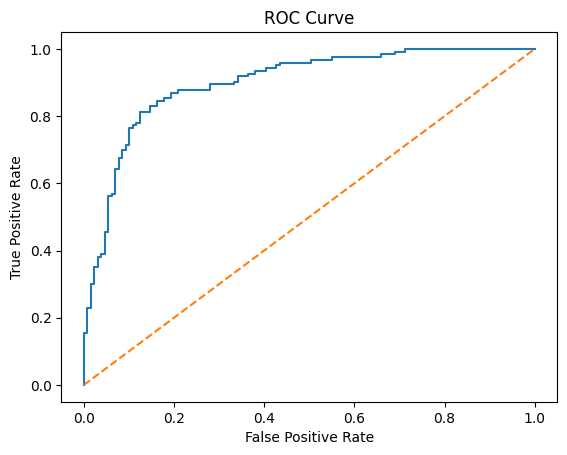


=== CROSS VALIDATION ===
Scores: [0.80952381 0.82539683 0.82142857 0.86111111 0.74900398]
Mean : 0.8132928603048125

=== FEATURE IMPORTANCE ===
           feature  importance
5   work_interfere    0.331144
4   family_history    0.093139
0              Age    0.071856
10    care_options    0.060783
1           Gender    0.044910
2          Country    0.041597
6     no_employees    0.035246
9         benefits    0.032194
14           leave    0.031257
17       coworkers    0.024104


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score

# EVALUASI MODEL LENGKAP
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# 1. PREDIKSI
y_pred = model.predict(X_test)

# Jika model support probability (RandomForest support)
y_prob = model.predict_proba(X_test)[:, 1]

# 2. METRICS UTAMA
print("=== METRICS ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Yes"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
# 3. CLASSIFICATION REPORT
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# 4. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

# 5. ROC AUC SCORE
# NOTE: y_test masih string ("Yes"/"No"), jadi perlu mapping
y_test_binary = y_test.map({"No": 0, "Yes": 1})

roc_auc = roc_auc_score(y_test_binary, y_prob)
print("\nROC-AUC Score:", roc_auc)

# 6. PLOT ROC CURVE
fpr, tpr, _ = roc_curve(y_test_binary, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 7. CROSS VALIDATION
cv_scores = cross_val_score(model, X, y, cv=5)

print("\n=== CROSS VALIDATION ===")
print("Scores:", cv_scores)
print("Mean :", cv_scores.mean())

# 8. FEATURE IMPORTANCE (Random Forest)
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(feature_importance.head(10))


In [ ]:
#tes nlp
from nlp import extract_features

text = "Saya sangat cemas dan tidak bisa tidur"

print(extract_features(text))

{'sleep_quality': 'Poor', 'stress_level': 'Often'}
